# Getting price for reference items

I'm done entering all my receipts. Each expense is matched with a product, which is matched with a reference item. The reference item is the non-gluten-free product that we calculate the price difference with. 

Things we'll need for each reference item:
- Price
- Weight
- URL
- Screenshot (as proof)
- Time stamp of scrape

After the initial attempt to search and save scraping: 
- Walmart.ca is difficult to scrape, I'll try another website
- Instead of the reference item name, I'll add actual product names to simplify search

Todo db changes: 
- Need a table for scrapes with url, info, timestamp
- Reference item: keep name, but remove info, link to latest product scrape

In [17]:
%pip install -q pandas


[notice] A new release of pip is available: 24.3.1 -> 25.0
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [18]:
import pandas as pd

## Load list of product names

In [19]:
df_mapping = pd.read_csv('reference_products_mapping.csv')
df_mapping.head(20)

,id,name,product_name
0,1,BBQ Sauce,Kraft BBQ Sauce
1,2,Beans,Canned black beans
2,3,Bouillon cubes,Knorr Chicken Bouillon
3,4,Candy,Maynards Swedish Berries
4,5,Cereal,Corn flakes cereal
5,6,Chia seeds,Bulk Chia Seeds
6,7,Chips,Lay's Classic Chips
7,8,Chocolate,Hershey's Milk Chocolate Bar
8,9,Chocolate chips,Hershey's Semi-Sweet Chocolate Chips
9,10,Cookies,Oreo Cookies


## Get the goods

In [20]:
%pip install -q \
    requests \
    bs4 \
    fake_useragent


[notice] A new release of pip is available: 24.3.1 -> 25.0
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### First: find product (cheapest), get product page URL (screenshot)

In [22]:
%pip install -q selenium webdriver-manager IPython


[notice] A new release of pip is available: 24.3.1 -> 25.0
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [48]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager
import os
from IPython.display import Image, display

def create_driver():
    # Set up Chrome options
    chrome_options = Options()
    chrome_options.add_argument("--headless")
    chrome_options.add_argument("--window-size=1280x900")
    chrome_options.add_argument(f"user-agent='Mozilla/5.0 (Macintosh; Intel Mac OS X 10_10_1) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/39.0.2171.95 Safari/537.36'")
    # Initialize the Chrome driver
    driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=chrome_options)
    return driver

def remove_consent_banner(driver):
    # Remove the div with id "onetrust-consent-sdk"
    try:
        consent_div = WebDriverWait(driver, 10).until(
            EC.presence_of_element_located((By.ID, "onetrust-consent-sdk"))
        )
        driver.execute_script("arguments[0].element.parentNode.removeChild(element);", consent_div)
    except Exception as e:
        print(f"Could not find or remove the consent div: {e}")

In [49]:
# cleaner version

import json
import os
from typing import Dict
import requests
from bs4 import BeautifulSoup
from datetime import datetime, timezone
import random
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
import time

# https://www.foodbasics.ca/search?sortOrder=price-asc&filter={query}
# https://www.walmart.ca/en/search?q={query}&sort=price_low

def get_url(query, domain="https://www.foodbasics.ca"):
    query = query.replace(" ","+")
    website=domain+f"/search?sortOrder=price-asc&filter={query}"
    return website

def peak(driver):
    # for debugging
    if not os.path.exists('./.temp'):
        os.makedirs('./.temp')
    timestamp = pd.Timestamp.now().strftime('%Y-%m-%d_%H-%M-%S')
    save_path = f"./.temp/{query}_{timestamp}.png"
    driver.save_screenshot(save_path)
    display(Image(filename=save_path, width=500))
    os.remove(save_path)

def dump_scrape(items):
    # for debugging
    # place to dump scrapes, just in case need to re-run, keeping it simple
    # in an app, nosql would be a good choice because scrapes might have different attributes
    with open(f'./scrapes_dump.json', 'a') as file:
        for item in items:
            json.dump(item, file, indent=4)
            file.write(",\n")
    print(f'Saved {len(items)} item(s)')

def scrape_search(query):
    driver = create_driver()
    driver.get( get_url(query) )
    time.sleep(5)  # Wait for the page to load
    items = []
    products = driver.find_elements(By.CLASS_NAME, 'default-product-tile')
    for product in products:
        title = product.find_element(By.CLASS_NAME, 'head__title').text.strip()
        unit_details = product.find_element(By.CLASS_NAME, 'head__unit-details').text.strip()
        sale_price = product.find_element(By.CSS_SELECTOR, 'div.content__pricing div[data-main-price]').get_attribute('data-main-price')
        secondary_price = product.find_element(By.CLASS_NAME, 'pricing__secondary-price').text.strip()
        product_url = product.find_element(By.CLASS_NAME, 'product-details-link').get_attribute('href')
        clean_item = clean_up_item({
            'title': title,
            'weight': unit_details,
            'price': sale_price,
            'price_per_unit': secondary_price,
            'url': product_url
        })
        items.append(clean_item)

    # debug
    peak(driver)

    dump_scrape(items)

    driver.quit()

    return items

def get_cheapest(items):
    print(f"Getting cheapest of len(items) item(s):")
    sorted_items = sorted([item for item in items if item['pricePerWeight'] is not None], key=lambda x: x['pricePerWeight'])
    cheapest = sorted_items[0]
    print(cheapest)
    return cheapest

def clean_up_item(scraped_item: Dict) -> Dict:
    def get_clean_price(price: str) -> float:
        price = float(scraped_item['price'].replace('$', ''))
        return price
    price = get_clean_price(scraped_item['price'])

    def get_clean_quantity(weight: str) -> float:
        if 'x' in weight:
            parts = weight.split('x')
            multiplier = float(parts[0].strip())
            unit = float(parts[1].split()[0])
            quantity = multiplier * unit
            return quantity
        else:
            return float(scraped_item['weight'].split()[0])
    quantity = get_clean_quantity(scraped_item['weight'])

    def calculate_price_per_weight(quantity: float, price: float) -> float:
        return price / quantity

    return {
        'name': scraped_item['title'],
        'quantity': quantity,
        'unitOfMeasure': scraped_item['weight'].split()[1],
        'price': price,
        'pricePerWeight': calculate_price_per_weight(quantity, price),
        'referenceUrl': scraped_item['url'],
        'createdAt': datetime.now(timezone.utc).isoformat(timespec='milliseconds').replace('+00:00', 'Z')
    }

### Get the screenshot

In [ ]:
import sqlite3

def save_item(item, screenshot_filename):
    item['screenshot'] = screenshot_filename
    # add to sqlite
    conn = sqlite3.connect('db_test.db')
    c = conn.cursor()

    c.execute('''
        CREATE TABLE IF NOT EXISTS product_price_proof (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            name TEXT,
            quantity TEXT,
            unitOfMeasure TEXT,
            price REAL,
            pricePerWeight REAL,
            referenceUrl TEXT,
            screenshot TEXT,
            createdAt TEXT,
            reference_item_id INT
        )
    ''')

    c.execute('''
        INSERT INTO product_price_proof (name, quantity, unitOfMeasure, price, pricePerWeight, referenceUrl, screenshot, createdAt, reference_item_id)
        VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?)
    ''', (item['name'], item['quantity'], item['unitOfMeasure'], item['price'], item['pricePerWeight'], item['referenceUrl'], item['screenshot'], item['createdAt'], item['reference_item_id']))

    conn.commit()
    conn.close()
    print(f"Saved item {item}")

def save_screencapture(driver, product_name_query):
    error out i'm not ready
    # Create the screenshots directory if it doesn't exist
    os.makedirs('./screenshots', exist_ok=True)

    # Save the screenshot
    timestamp = pd.Timestamp.now().strftime('%Y-%m-%d_%H-%M-%S')
    save_path = f"./screenshots/{product_name_query}_{timestamp}.png"
    driver.save_screenshot(save_path)

    return save_path

def save_proof():
    driver = create_driver()
    # Open the URL
    driver.get(url)
    # ...
    # Quit the driver
    driver.quit()

## Connceting in bulk

In [32]:
def auto_search(product_name_query, reference_item_id):
    print(f"get items for {product_name_query}")
    items = scrape_search(product_name_query)
    
    # guard clause
    if len(items) <= 1:
        print(f"Query {get_url(product_name_query)} did not return any items!")
        return
    for item in items:
        item['reference_item_id'] = int(reference_item_id)

    target_item = get_cheapest(items)

    save_filename = f'./screenshots/{reference_item_id}_{product_name_query}_{target_item['createdAt']}.png'
    save_screencapture(target_item['referenceUrl'], save_filename)
    save_proof(target_item)

    target_item['screenshot'] = save_filename
    display(Image(filename=save_filename, width=500))

In [27]:
# first one run
# auto_search(product_name_query=df_mapping.iloc[8]['product_name'], reference_item_id=df_mapping.iloc[8]['id'])

In [28]:
import pandas as pd

def get_product_proofs():
    # Connect to the SQLite database
    conn = sqlite3.connect('db_test.db')
    c = conn.cursor()

    # Execute a query to select all rows from the product_price_proof table
    c.execute('SELECT * FROM product_price_proof')

    # Fetch all rows from the executed query
    rows = c.fetchall()

    # Print the column names
    column_names = [description[0] for description in c.description]

    # Create a DataFrame from the fetched rows
    df = pd.DataFrame(rows, columns=column_names)

    # Close the connection
    conn.close()

    # Display the DataFrame
    return df

product_proofs = get_product_proofs()
# display(product_proofs)

proofs_we_have = product_proofs["reference_item_id"].tolist()
proofs_we_need = df_mapping["id"].tolist()
missing_proofs = list(set(proofs_we_need) - set(proofs_we_have))
print(f"""{len(missing_proofs)} proof(s) missing""")

91 proof(s) missing


#### Data management thoughts

- I don't want to polute the main db with endless scrapes of all items, I don't really need all the items; it's just a safety net for analysis right now to not have to scrape everything all over again
- I don't mind however having the list of products to grow long, because in the ideal case this would have a daily price update, so that the diff in the price is close to the compartor on the same date. There are about 100 reference items, so it would be about 35k entries per year, it's manageable. I can archive/condense the data as years go by. 
- I don't think this structure is ideal, but I don't want to spend time right now fixing it (e.g. screenshots would be better store as key to another table, timestamps standardized, ...)

TODO
- [x] Add reference_item ID to scrape (both target item and dump)
- [x] clean up data (prices, weight, etc), match app data structure
- [x] Generate list log of products that didn't yield results to easily query them later

### Run a batch

In [29]:
# import os

# def CLEANSTATE():
#     # Delete the database file if it exists
#     if os.path.exists('db_test.db'):
#         os.remove('db_test.db')
#         print("Deleted db_test.db")

#     # Delete the scrapes dump file if it exists
#     if os.path.exists('scrapes_dump.json'):
#         os.remove('scrapes_dump.json')
#         print("Deleted scrapes_dump.json")

# # DESTRUCTIVE
# CLEANSTATE()

🏃 run 2 Canned black beans
get items for Canned black beans


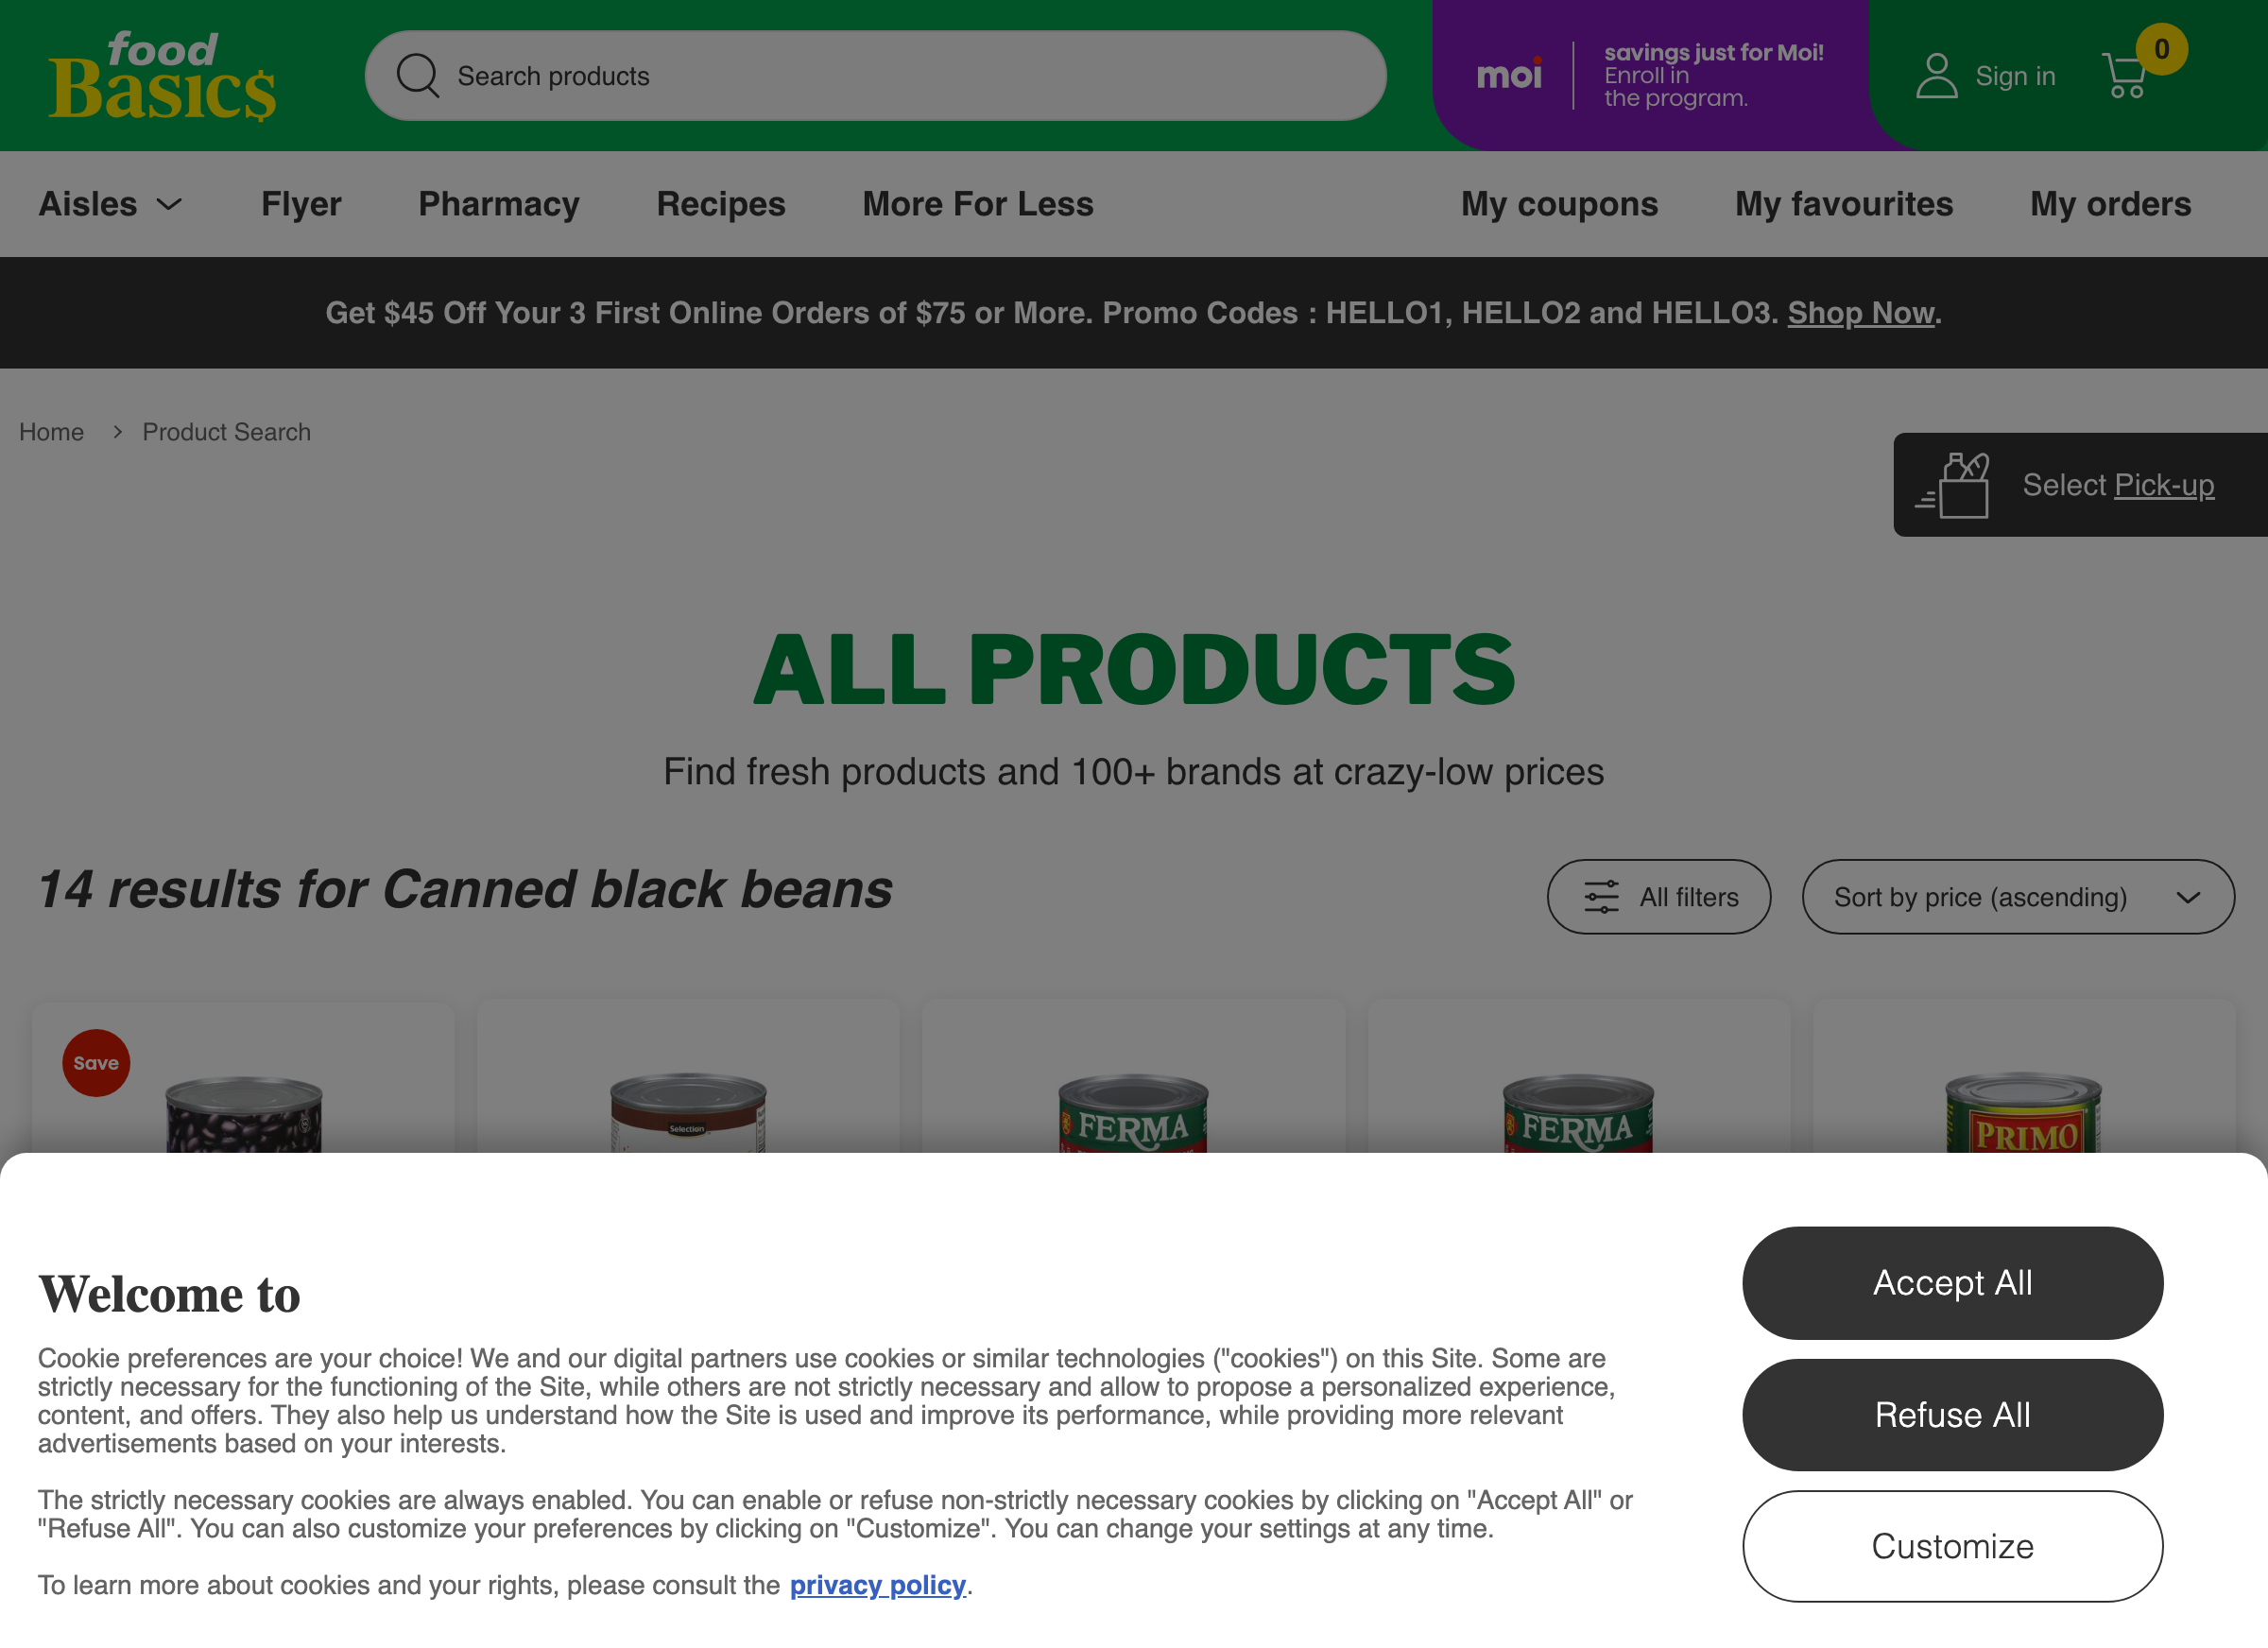

Saved 14 item(s)
get cheapest
Getting cheapest of len(items) item(s):
{'name': 'Black Turtle Beans', 'quantity': 540.0, 'unitOfMeasure': 'mL', 'price': 1.49, 'pricePerWeight': 0.002759259259259259, 'referenceUrl': 'https://www.foodbasics.ca/aisles/pantry/canned-jarred/beans-legumes/black-turtle-beans/p/062356500047', 'createdAt': '2025-02-02T17:32:07.231Z', 'reference_item_id': 2}
{'name': 'Black Turtle Beans', 'quantity': 540.0, 'unitOfMeasure': 'mL', 'price': 1.49, 'pricePerWeight': 0.002759259259259259, 'referenceUrl': 'https://www.foodbasics.ca/aisles/pantry/canned-jarred/beans-legumes/black-turtle-beans/p/062356500047', 'createdAt': '2025-02-02T17:32:07.231Z', 'reference_item_id': 2}


KeyboardInterrupt: 

In [ ]:
import time
import random

# Run the list
# for index, row in df_mapping.iterrows():
#     print(f"Index: {index}")
#     auto_search(product_name_query=row['product_name'], reference_item_id=row['id'])
#     time.sleep(random.uniform(5, 10))

for proof_id in missing_proofs:
    row = df_mapping[df_mapping['id'] == proof_id].iloc[0]
    print(f"🏃 run {row['id']} {row['product_name']}")
    auto_search(product_name_query=row['product_name'], reference_item_id=row['id'])
    time.sleep(random.uniform(5, 10))